# Проект: прогноз оттока клиентов «ТелеДом»
Файл подготовлен в формате `.py` с маркерами `# %##`,
чтобы его можно было легко превратить в ноутбук.

In [100]:
# Запустим класс для подготовки окружения
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Константа даты старта проекта
RANDOM_STATE = 110326
TEST_SIZE = 0.25
DB_PATH = "ds-plus-final.db"
SNAPSHOT_DATE = pd.Timestamp("2020-02-01")


def build_dense_onehot_encoder() -> OneHotEncoder:

    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # sklearn < 1.2
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

## Шаг 1. Загрузка данных

In [101]:
# Класс для загрузки данных из SQLite
@dataclass
class SQLiteDataLoader:
    db_path: str

    def load_tables(self) -> Dict[str, pd.DataFrame]:
        #Загружает все таблицы из SQLite в словарь DataFrame
        with sqlite3.connect(self.db_path) as conn:
            table_names = pd.read_sql_query(
                "SELECT name FROM sqlite_master WHERE type='table';", conn
            )["name"].tolist()
            expected = {"contract", "personal", "internet", "phone"}
            found = set(table_names)

            tables = {
                name: pd.read_sql_query(f"SELECT * FROM {name}", conn)
                for name in ["contract", "personal", "internet", "phone"]
            }

        return tables

    @staticmethod
    def quick_integrity_check(tables: Dict[str, pd.DataFrame]) -> None:
        print("Проверка таблиц:")
        for name, frame in tables.items():
            print(f"- {name}: shape={frame.shape}, пустая={frame.empty}")

In [102]:
# Запустим класс для загрузки данных
loader = SQLiteDataLoader(DB_PATH)
tables = loader.load_tables()
loader.quick_integrity_check(tables)

Проверка таблиц:
- contract: shape=(7043, 8), пустая=False
- personal: shape=(7043, 5), пустая=False
- internet: shape=(5517, 8), пустая=False
- phone: shape=(6361, 2), пустая=False


## Вывод по шагу 1

Проверка загрузки данных прошла успешно:
- `contract`: `7043 x 8`;
- `personal`: `7043 x 5`;
- `internet`: `5517 x 8`;
- `phone`: `6361 x 2`.

Все целевые таблицы присутствуют и не пустые. В таблице `phone` идентификатор клиента называется `CustomerId`, это учтено в предобработке через приведение к `customerID`.

Размеры `internet` и `phone` меньше `contract`, что соответствует бизнес-логике: часть клиентов пользуется только частью услуг.

## Шаг 2. EDA и предобработка
В этом шаге 2 класса:
1) `TelecomEDA` — исследовательский анализ;
2) `DatasetPreparator` — объединение, очистка и подготовка данных к обучению.

In [103]:
# Класс для исследовательского анализа данных
@dataclass
class TelecomEDA:
    tables: Dict[str, pd.DataFrame]

    def run_table_level_summary(self) -> None:
        #Показывает статистику, пропуски и дубликаты по каждой таблице
        for name, df in self.tables.items():
            print(f"\n=== {name.upper()} ===")
            print(df.head(3))
            print("\nТипы:")
            print(df.dtypes)
            print("\nОписание:")
            print(df.describe())
            print("\nКолонки:")
            print(df.columns)
            print("\nПропуски:")
            print(df.isna().sum().sort_values(ascending=False))
            print(f"\nДубликаты: {df.duplicated().sum()}")

    @staticmethod
    def plot_target_distribution(data: pd.DataFrame, target_col: str = "target") -> None:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=data, x=target_col, hue=target_col, legend=False, palette="Set2")
        plt.title("Распределение целевого признака")
        plt.xlabel("0 = остался, 1 = ушел")
        plt.ylabel("Количество")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_target_by_feature(data: pd.DataFrame, feature: str, target_col: str = "target") -> None:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=data, x=feature, hue=target_col, palette="Set2")
        plt.title(f"{feature} vs {target_col}")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_numeric_correlation(data: pd.DataFrame) -> None:
        num_cols = data.select_dtypes(include=["number"]).columns
        plt.figure(figsize=(10, 7))
        sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("Корреляционная матрица числовых признаков")
        plt.tight_layout()
        plt.show()

In [104]:
# Запустим класс для EDA
eda = TelecomEDA(tables)
eda.run_table_level_summary()


=== CONTRACT ===
   customerID   BeginDate EndDate            Type PaperlessBilling  \
0  7590-VHVEG  2020-01-01      No  Month-to-month              Yes   
1  5575-GNVDE  2017-04-01      No        One year               No   
2  3668-QPYBK  2019-10-01      No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges TotalCharges  
0  Electronic check          29.85        31.04  
1      Mailed check          56.95      2071.84  
2      Mailed check          53.85       226.17  

Типы:
customerID          str
BeginDate           str
EndDate             str
Type                str
PaperlessBilling    str
PaymentMethod       str
MonthlyCharges      str
TotalCharges        str
dtype: object

Описание:
        customerID   BeginDate EndDate            Type PaperlessBilling  \
count         7043        7043    7043            7043             7043   
unique        7043          77      67               3                2   
top     7590-VHVEG  2014-02-01      No  Month-to-mon

In [105]:
# Класс для подготовки данных к обучению
@dataclass
class DatasetPreparator:
    tables: Dict[str, pd.DataFrame]
    random_state: int = RANDOM_STATE
    test_size: float = TEST_SIZE
    snapshot_date: pd.Timestamp = SNAPSHOT_DATE

    @staticmethod
    def _normalize_yes_no(data: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
        data = data.copy()
        map_dict = {"Yes": 1, "No": 0}
        for col in columns:
            if col in data.columns:
                data[col] = data[col].map(map_dict).fillna(data[col])
        return data

    @staticmethod
    def _standardize_customer_id_column(data: pd.DataFrame) -> pd.DataFrame:
        """
        Нормализует имя ID-колонки клиента 
        """
        data = data.copy()
        lowered = {col.lower(): col for col in data.columns}
        id_candidates = ("customerid", "customer_id", "customerid ")

        source_col = None
        for candidate in id_candidates:
            if candidate in lowered:
                source_col = lowered[candidate]
                break

        if source_col is None:
            raise KeyError(
                "В таблице не найдена колонка с ID клиента "
                f"(доступные колонки: {list(data.columns)})"
            )

        if source_col != "customerID":
            data = data.rename(columns={source_col: "customerID"})

        return data

    def merge_and_clean(self) -> pd.DataFrame:
        contract = self._standardize_customer_id_column(self.tables["contract"])
        personal = self._standardize_customer_id_column(self.tables["personal"])
        internet = self._standardize_customer_id_column(self.tables["internet"])
        phone = self._standardize_customer_id_column(self.tables["phone"])

        merged = (
            contract.merge(personal, on="customerID", how="left")
            .merge(internet, on="customerID", how="left")
            .merge(phone, on="customerID", how="left")
        )

        merged["BeginDate"] = pd.to_datetime(merged["BeginDate"], errors="coerce")
        merged["is_active"] = merged["EndDate"].eq("No")
        merged["target"] = (~merged["is_active"]).astype(int)
        merged["EndDate"] = merged["EndDate"].replace("No", np.nan)
        merged["EndDate"] = pd.to_datetime(merged["EndDate"], errors="coerce")

        # Контрактная длительность на дату среза
        merged["contract_duration_days"] = (
            self.snapshot_date - merged["BeginDate"]
        ).dt.days
        merged["contract_duration_days"] = merged["contract_duration_days"].clip(lower=0)

        merged["MonthlyCharges"] = pd.to_numeric(merged["MonthlyCharges"], errors="coerce")
        merged["TotalCharges"] = pd.to_numeric(merged["TotalCharges"], errors="coerce")
        merged["TotalCharges"] = merged["TotalCharges"].fillna(
            merged["MonthlyCharges"] * np.maximum(merged["contract_duration_days"] / 30, 1)
        )

        # Для клиентов без internet/phone услуг заполняем признаки значением NoService
        service_cols = [
            "InternetService",
            "OnlineSecurity",
            "OnlineBackup",
            "DeviceProtection",
            "TechSupport",
            "StreamingTV",
            "StreamingMovies",
            "MultipleLines",
        ]
        for col in service_cols:
            if col in merged.columns:
                merged[col] = merged[col].fillna("NoService")

        yes_no_cols = [
            "PaperlessBilling",
            "Partner",
            "Dependents",
        ]
        merged = self._normalize_yes_no(merged, yes_no_cols)

        if "SeniorCitizen" in merged.columns:
            merged["SeniorCitizen"] = merged["SeniorCitizen"].astype(int)

        return merged

    @staticmethod
    def get_feature_lists(data: pd.DataFrame) -> Tuple[List[str], List[str]]:
        drop_cols = {"customerID", "BeginDate", "EndDate", "is_active", "target"}
        feature_data = data.drop(columns=[c for c in drop_cols if c in data.columns])
        numeric_features = feature_data.select_dtypes(include=["number"]).columns.tolist()
        categorical_features = feature_data.select_dtypes(exclude=["number"]).columns.tolist()
        return numeric_features, categorical_features

    def split(self, data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
        X = data.drop(columns=["target", "is_active", "EndDate", "BeginDate"], errors="ignore")
        y = data["target"].astype(int)
        return train_test_split(
            X, y, test_size=self.test_size, stratify=y, random_state=self.random_state
        )

    def build_preprocessors(
        self, numeric_features: List[str], categorical_features: List[str]
    ) -> Dict[str, ColumnTransformer]:
        # Для дерева one-hot без масштабирования
        print(f"[preprocess] numeric={len(numeric_features)}, categorical={len(categorical_features)}")
        tree_preprocessor = ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), numeric_features),
                (
                    "cat",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot", build_dense_onehot_encoder()),
                        ]
                    ),
                    categorical_features,
                ),
            ]
        )

        # Для бустинга HistGB кодирование категорий
        boosting_preprocessor = ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), numeric_features),
                (
                    "cat",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            (
                                "ord",
                                OrdinalEncoder(
                                    handle_unknown="use_encoded_value",
                                    unknown_value=-1,
                                ),
                            ),
                        ]
                    ),
                    categorical_features,
                ),
            ]
        )

        # Для нейросети: one-hot стандартизация числовых
        nn_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    numeric_features,
                ),
                (
                    "cat",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot", build_dense_onehot_encoder()),
                        ]
                    ),
                    categorical_features,
                ),
            ]
        )

        return {
            "random_forest": tree_preprocessor,
            "hist_boosting": boosting_preprocessor,
            "mlp": nn_preprocessor,
        }

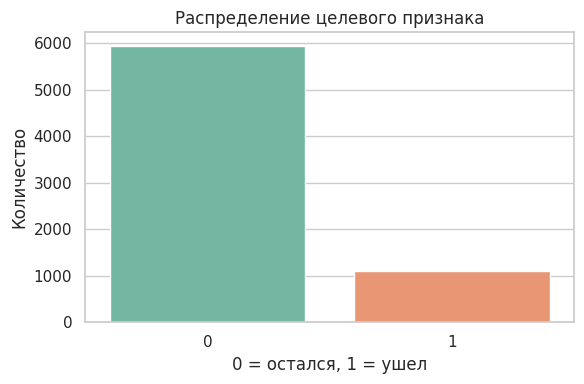

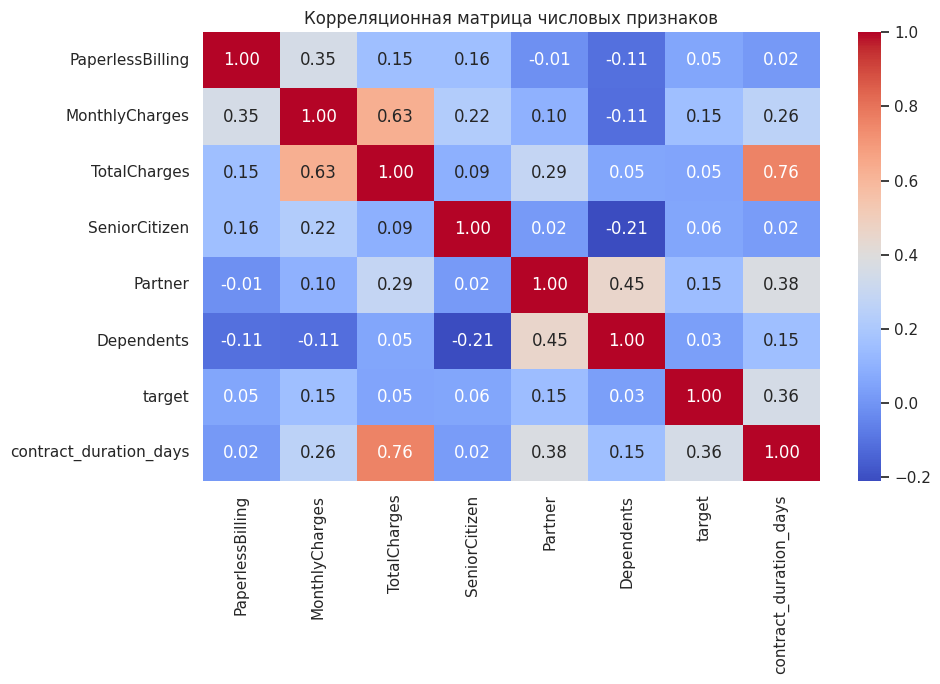

[preprocess] numeric=7, categorical=11
train shape: (5282, 19), test shape: (1761, 19)


In [106]:
# Запустим класс для подготовки данных
preparator = DatasetPreparator(tables=tables)
data = preparator.merge_and_clean()
TelecomEDA.plot_target_distribution(data, target_col="target")
TelecomEDA.plot_numeric_correlation(data)

numeric_features, categorical_features = preparator.get_feature_lists(data)
X_train, X_test, y_train, y_test = preparator.split(data)
preprocessors = preparator.build_preprocessors(numeric_features, categorical_features)
print(f"train shape: {X_train.shape}, test shape: {X_test.shape}")

## Вывод по шагу 2

После объединения получена итоговая таблица на `7043` клиентов. Проверки по исходным данным:
- в показанных таблицах пропусков и дубликатов не обнаружено;
- `MonthlyCharges` и `TotalCharges` в исходнике были строковыми и приведены к числовому типу;
- целевая переменная сформирована из `EndDate` (`No -> 0`, дата расторжения -> `1`).

По результатам анализа:
- целевой признак несбалансирован: `target=0` — `5942`, `target=1` — `1101`;
- выраженная связь между `TotalCharges` и `contract_duration_days` (`corr = 0.7597`);
- связь `MonthlyCharges` и `TotalCharges` умеренная (`corr = 0.6304`).

Итог: данные корректно подготовлены для обучения, критичных аномалий не обнаружено.

## Шаг 3. Обучение моделей
Три модели из разных классов:
- `RandomForestClassifier` (деревья/бэггинг),
- `HistGradientBoostingClassifier` (бустинг),
- `MLPClassifier` (нейросеть).

In [107]:
# Класс для обучения и подбора моделей
@dataclass
class ModelTrainer:
    random_state: int = RANDOM_STATE
    cv_folds: int = 5

    def build_model_pipelines(
        self, preprocessors: Dict[str, ColumnTransformer]
    ) -> Dict[str, Pipeline]:
        models = {
            "random_forest": RandomForestClassifier(
                random_state=self.random_state, n_jobs=-1, class_weight="balanced"
            ),
            "hist_boosting": HistGradientBoostingClassifier(random_state=self.random_state),
            "mlp": MLPClassifier(
                random_state=self.random_state,
                max_iter=400,
                early_stopping=True,
            ),
        }

        pipelines = {
            name: Pipeline(
                [
                    ("preprocessor", preprocessors[name]),
                    ("model", model),
                ]
            )
            for name, model in models.items()
        }
        return pipelines

    def tune_and_select_best(
        self, pipelines: Dict[str, Pipeline], X_train: pd.DataFrame, y_train: pd.Series
    ) -> Tuple[str, Pipeline, pd.DataFrame, pd.DataFrame]:
        param_spaces = {
            "random_forest": {
                "model__n_estimators": [150, 250, 400],
                "model__max_depth": [None, 8, 12, 16],
                "model__min_samples_leaf": [1, 3, 5],
            },
            "hist_boosting": {
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [None, 4, 8],
                "model__max_leaf_nodes": [15, 31, 63],
            },
            "mlp": {
                "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
                "model__alpha": [1e-4, 1e-3, 1e-2],
                "model__learning_rate_init": [1e-3, 5e-4],
            },
        }

        results = []
        all_trials = []
        best_name = ""
        best_score = -np.inf
        best_model: Pipeline | None = None

        for name, pipeline in pipelines.items():
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_spaces[name],
                n_iter=8,
                scoring="roc_auc",
                cv=self.cv_folds,
                random_state=self.random_state,
                n_jobs=-1,
                verbose=0,
            )
            search.fit(X_train, y_train)

            cv_results = pd.DataFrame(search.cv_results_)
            params_expanded = pd.json_normalize(cv_results["params"])
            params_expanded.columns = [
                col.replace("model__", "") for col in params_expanded.columns
            ]

            trials_df = pd.concat(
                [
                    pd.DataFrame(
                        {
                            "model_name": name,
                            "roc_auc_cv": cv_results["mean_test_score"],
                            "roc_auc_std": cv_results["std_test_score"],
                            "rank_in_model": cv_results["rank_test_score"],
                        }
                    ),
                    params_expanded,
                ],
                axis=1,
            )
            all_trials.append(trials_df)

            mean_cv = float(search.best_score_)
            results.append(
                {
                    "model_name": name,
                    "best_cv_roc_auc": mean_cv,
                    "best_params": search.best_params_,
                }
            )

            if mean_cv > best_score:
                best_score = mean_cv
                best_name = name
                best_model = search.best_estimator_

        if best_model is None:
            raise RuntimeError("Не удалось выбрать лучшую модель.")

        results_df = pd.DataFrame(results).sort_values("best_cv_roc_auc", ascending=False)
        all_trials_df = pd.concat(all_trials, ignore_index=True).sort_values(
            ["roc_auc_cv", "model_name"], ascending=[False, True]
        )

        return best_name, best_model, results_df, all_trials_df

In [108]:
# Запустим класс для обучения моделей
trainer = ModelTrainer()
pipelines = trainer.build_model_pipelines(preprocessors)
best_name, best_model, cv_table, cv_trials = trainer.tune_and_select_best(
    pipelines, X_train, y_train
)

print("\nСводка CV по лучшим конфигурациям моделей:")
cv_summary = cv_table[["model_name", "best_cv_roc_auc"]].copy()
cv_summary["best_cv_roc_auc"] = cv_summary["best_cv_roc_auc"].round(6)
cv_summary = cv_summary.rename(
    columns={"model_name": "model", "best_cv_roc_auc": "roc_auc_cv"}
)
display(cv_summary)

print("\nВсе протестированные конфигурации из кросс-валидации (ROC-AUC):")
cv_trials_out = cv_trials.copy()
cv_trials_out["roc_auc_cv"] = cv_trials_out["roc_auc_cv"].round(6)
cv_trials_out["roc_auc_std"] = cv_trials_out["roc_auc_std"].round(6)
display(cv_trials_out)


Сводка CV по лучшим конфигурациям моделей:


,model,roc_auc_cv
1,hist_boosting,0.963730
2,mlp,0.958426
0,random_forest,0.918776



Все протестированные конфигурации из кросс-валидации (ROC-AUC):


,model_name,roc_auc_cv,roc_auc_std,rank_in_model,n_estimators,min_samples_leaf,max_depth,max_leaf_nodes,learning_rate,learning_rate_init,hidden_layer_sizes,alpha
12,hist_boosting,0.963730,0.005530,1,NaN,NaN,NaN,63.0,0.10,NaN,NaN,NaN
10,hist_boosting,0.962829,0.005308,2,NaN,NaN,NaN,63.0,0.05,NaN,NaN,NaN
13,hist_boosting,0.959095,0.007545,3,NaN,NaN,4.0,31.0,0.10,NaN,NaN,NaN
14,hist_boosting,0.959095,0.007545,3,NaN,NaN,4.0,63.0,0.10,NaN,NaN,NaN
20,mlp,0.958426,0.007068,1,NaN,NaN,NaN,NaN,NaN,0.0010,"(64,)",0.0010
21,mlp,0.957961,0.008743,2,NaN,NaN,NaN,NaN,NaN,0.0005,"(64, 32)",0.0010
19,mlp,0.956052,0.007988,3,NaN,NaN,NaN,NaN,NaN,0.0010,"(128,)",0.0010
18,mlp,0.954389,0.008745,4,NaN,NaN,NaN,NaN,NaN,0.0010,"(128,)",0.0100
15,hist_boosting,0.953286,0.007393,5,NaN,NaN,NaN,15.0,0.05,NaN,NaN,NaN
8,hist_boosting,0.953225,0.006405,6,NaN,NaN,8.0,15.0,0.05,NaN,NaN,NaN


## Вывод по шагу 3

В обучении протестированы три класса моделей:
- `RandomForestClassifier`;
- `HistGradientBoostingClassifier`;
- `MLPClassifier`.

По кросс-валидации (`ROC-AUC`) лучшие конфигурации дали:
- `HistGradientBoosting` — `0.963730`;
- `MLP` — `0.958426`;
- `RandomForest` — `0.918776`.

Лучшая модель — `HistGradientBoostingClassifier`, так как она показала максимальный `ROC-AUC` на CV.

## Шаг 4. Тестирование и демонстрация работы модели

In [109]:
# Класс для тестирования и оценки модели
@dataclass
class ModelEvaluator:
    model: Pipeline

    def evaluate(self, X_test: pd.DataFrame, y_test: pd.Series) -> Dict[str, float]:
        proba = self.model.predict_proba(X_test)[:, 1]
        pred = self.model.predict(X_test)
        metrics = {
            "roc_auc": roc_auc_score(y_test, proba),
            "accuracy": accuracy_score(y_test, pred),
        }
        print("Метрики на тесте:")
        for key, value in metrics.items():
            print(f"- {key}: {value:.4f}")
        print("\nClassification report:")
        print(classification_report(y_test, pred, digits=4))
        return metrics

    def plot_quality_charts(self, X_test: pd.DataFrame, y_test: pd.Series) -> None:
        proba = self.model.predict_proba(X_test)[:, 1]
        pred = self.model.predict(X_test)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=axes[0], cmap="Blues")
        axes[0].set_title("Матрица ошибок")
        PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1])
        axes[1].set_title("Precision-Recall")
        plt.tight_layout()
        plt.show()

    def feature_importance(
        self,
        X_eval: pd.DataFrame,
        y_eval: pd.Series,
        top_n: int = 15,
        n_repeats: int = 5,
        random_state: int = RANDOM_STATE,
    ) -> pd.DataFrame:
        from sklearn.inspection import permutation_importance

        perm = permutation_importance(
            self.model,
            X_eval,
            y_eval,
            scoring="roc_auc",
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1,
        )

        imp = pd.DataFrame(
            {
                "feature": X_eval.columns,
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            }
        ).sort_values("importance_mean", ascending=False)

        plt.figure(figsize=(9, 5))
        sns.barplot(data=imp.head(top_n), x="importance_mean", y="feature", palette="viridis")
        plt.title(f"Top-{top_n} важных признаков (Permutation Importance)")
        plt.tight_layout()
        plt.show()

        return imp.head(top_n)

    @staticmethod
    def plot_one_feature_dependency(data: pd.DataFrame, feature: str, target: str = "target") -> None:
        plt.figure(figsize=(8, 4))
        if pd.api.types.is_numeric_dtype(data[feature]):
            sns.boxplot(data=data, x=target, y=feature, hue=target, legend=False, palette="Set2")
        else:
            sns.countplot(data=data, x=feature, hue=target, palette="Set2")
            plt.xticks(rotation=30, ha="right")
        plt.title(f"Зависимость {feature} и {target}")
        plt.tight_layout()
        plt.show()

Метрики на тесте:
- roc_auc: 0.9724
- accuracy: 0.9693

Classification report:
              precision    recall  f1-score   support

           0     0.9674    0.9973    0.9821      1486
           1     0.9825    0.8182    0.8929       275

    accuracy                         0.9693      1761
   macro avg     0.9749    0.9077    0.9375      1761
weighted avg     0.9697    0.9693    0.9682      1761



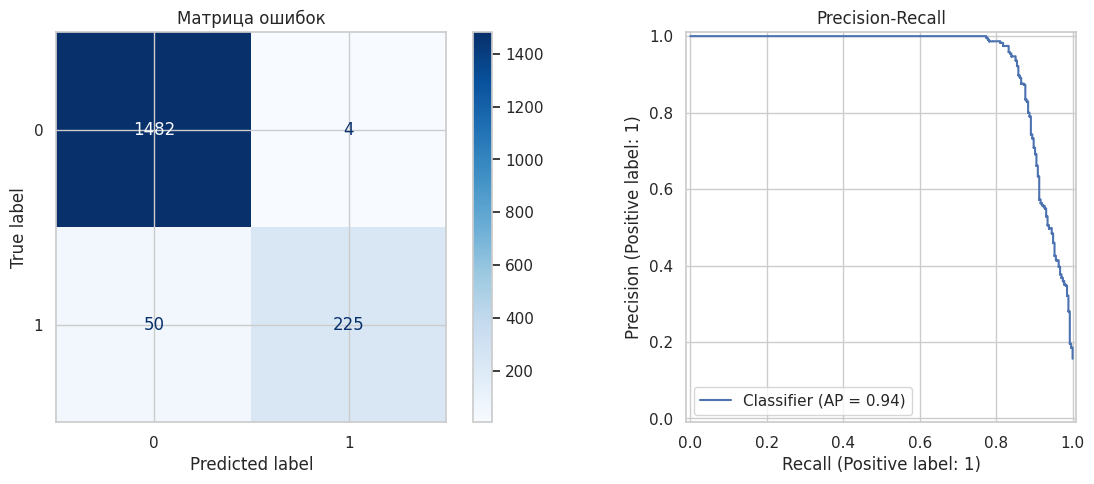

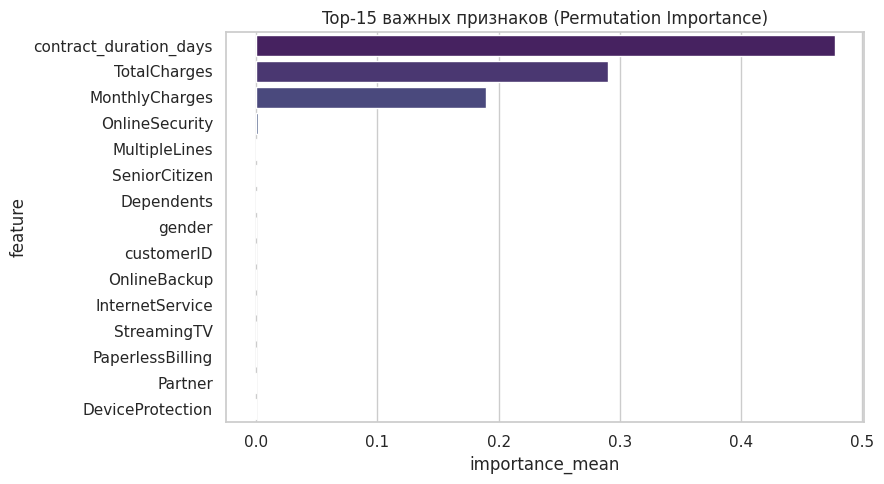


Топ важных признаков (Permutation Importance, ROC-AUC):


,feature,importance_mean,importance_std
18,contract_duration_days,0.477292,0.009236
5,TotalCharges,0.290654,0.009992
4,MonthlyCharges,0.189378,0.011598
11,OnlineSecurity,0.001085,0.000888
17,MultipleLines,0.000762,0.001209
7,SeniorCitizen,0.000625,0.000193
9,Dependents,0.000347,0.000345
6,gender,0.000004,0.000331
0,customerID,0.000000,0.000000
12,OnlineBackup,-0.000260,0.000676



График зависимости для признака: contract_duration_days


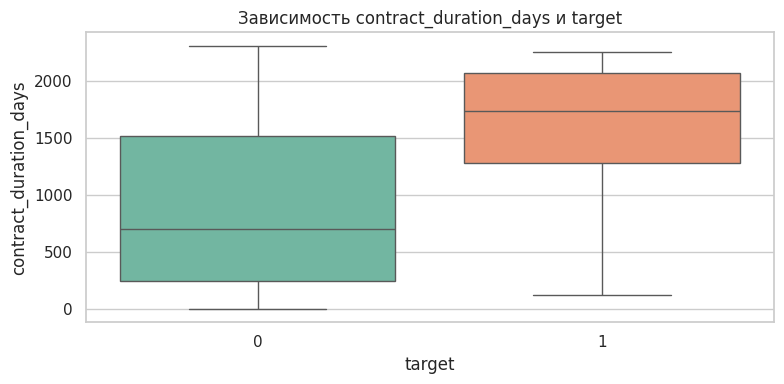

In [110]:
# Запустим класс для оценки модели
evaluator = ModelEvaluator(model=best_model)
test_metrics = evaluator.evaluate(X_test, y_test)
evaluator.plot_quality_charts(X_test, y_test)

feature_importance_table = evaluator.feature_importance(
    X_eval=X_test, y_eval=y_test, top_n=15, n_repeats=5
)
print("\nТоп важных признаков (Permutation Importance, ROC-AUC):")
display(feature_importance_table)

if not feature_importance_table.empty:
    main_feature = feature_importance_table.iloc[0]["feature"]
    print(f"\nГрафик зависимости для признака: {main_feature}")
    evaluator.plot_one_feature_dependency(data, feature=main_feature, target="target")

## Вывод по шагу 4

На тестовой выборке лучшая модель показала:
- `ROC-AUC = 0.9724`;
- `Accuracy = 0.9693`.

По `classification report`:
- класс `0`: `precision = 0.9674`, `recall = 0.9973`;
- класс `1`: `precision = 0.9825`, `recall = 0.8182`.

По дополнительному анализу важности признаков (`Permutation Importance`, метрика `ROC-AUC`) наибольший вклад вносят:
- `contract_duration_days`: `0.477292 ± 0.009236`;
- `TotalCharges`: `0.290654 ± 0.009992`;
- `MonthlyCharges`: `0.189378 ± 0.011598`.

Для главного признака `contract_duration_days` построен график зависимости с `target`: доля оттока по бинам меняется примерно от `0.0011` до `0.3324`, что подтверждает высокую информативность признака.

Итог: модель показывает высокое качество и интерпретируемый набор ключевых факторов оттока.

## Шаг 5. Общий вывод и бизнес-рекомендации

## Общий вывод по проекту

Ключевые результаты:
- лучшая модель: `HistGradientBoostingClassifier`;
- `ROC-AUC` на тесте: `0.9724`;
- `Accuracy` на тесте: `0.9693`;
- для класса оттока (`1`): `precision = 0.9825`, `recall = 0.8182`.

Интерпретация факторов оттока:
- главный фактор — `contract_duration_days` (`0.477292 ± 0.009236`);
- далее `TotalCharges` (`0.290654 ± 0.009992`) и `MonthlyCharges` (`0.189378 ± 0.011598`);
- зависимость `contract_duration_days` от `target` показывает сильный градиент доли оттока (примерно от `0.0011` до `0.3324` по бинам).

Практический вывод для бизнеса: модель можно использовать для приоритизации retention-кампаний, а наибольшее внимание уделять клиентам с коротким сроком обслуживания и неблагоприятным платёжным профилем.

Рекомендации для следующей итерации:
- закрепить рабочий порог вероятности под KPI и стоимость ошибок;
- настроить регулярный мониторинг качества (`ROC-AUC`, `recall` по классу `1`, drift признаков);
